# 05 — Cenários com Agrupamentos de Estado e Hibernando

## Objetivo

Testar se os apontamentos operacionais, especialmente `Hibernando`, ajudam ou atrapalham a previsão
do target provisório:

> início de pelo menos um novo episódio `Is_Dont_Go` nas próximas 8 horas.

O baseline do notebook 03 permanece congelado. Este notebook não muda:

- limpeza analítica;
- expurgo localizado da `PE3798`;
- deduplicação exata;
- definição inicial de sequência com gap de 60 segundos;
- janelas de observação/horizonte de 8 horas;
- lacuna global de `31/05/2025`;
- split temporal.

## Cenários testados

1. `RF_baseline_ids`: referência do notebook 03 com Random Forest e IDs.
2. `XGB_baseline_ids`: mesmo conjunto de features, usando XGBoost.
3. `XGB_estado_sem_hibernando`: adiciona estado operacional sem qualquer variável explícita de
   `Hibernando`.
4. `XGB_estado_com_hibernando`: adiciona proporções e estado dominante incluindo `Hibernando`.
5. `XGB_estado_flags_hibernando`: adiciona flags de presença de `Hibernando` e proxy de sobreposição.
6. `XGB_estado_flags_sem_CA65789`: repete o cenário 5 removendo `CA65789` de treino, validação e
   teste para medir sensibilidade ao caso de sobreposição já auditado.

Todos os thresholds são escolhidos na validação maximizando F2. O teste continua isolado.

In [1]:
from pathlib import Path
import time

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, confusion_matrix,
    f1_score, fbeta_score, precision_score, recall_score, roc_auc_score,
)
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 200)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
BASE = ROOT / "data" / "raw" / "Base"
TEL_GLOB = str(BASE / "datasets" / "telemetria" / "telemetry_*.parquet")
AP_PATH = str(BASE / "datasets" / "apontamentos" / "desenvolver_apontamentos.parquet")

SEQUENCE_GAP_SECONDS = 60
OBSERVATION_HOURS = 8
HORIZON_HOURS = 8
WINDOW_SECONDS = OBSERVATION_HOURS * 60 * 60
TOP_ALARM_IDS = 200
MISSING_DAY = pd.Timestamp("2025-05-31")
LOOP_TAG = "PE3798"
LOOP_DAY = pd.Timestamp("2025-06-29")
LOOP_ALARM_IDS = (1241582851, 1241582848)

con = duckdb.connect()
con.execute("SET threads=4")
con.execute("SET preserve_insertion_order=false")
con.execute(f"CREATE OR REPLACE VIEW tel AS SELECT * FROM read_parquet('{TEL_GLOB}', union_by_name=true)")
con.execute(f"CREATE OR REPLACE VIEW ap AS SELECT * FROM read_parquet('{AP_PATH}')")

def query(sql):
    return con.sql(sql).df()

print(f"Raiz do projeto: {ROOT}")
print("Cenários de estados usando a mesma base temporal do notebook 03.")

Raiz do projeto: /home/f_szekut/projects/vale_correct
Cenários de estados usando a mesma base temporal do notebook 03.


## 1. Reconstituição da base auditada

Esta seção reconstrói a base do notebook 03 para que o experimento seja independente e reproduzível.
Não há nova limpeza: as únicas exclusões seguem regras já aprovadas.

In [2]:
start = time.time()

con.execute(
    f'''
    CREATE OR REPLACE TEMP TABLE analytic_events AS
    SELECT
        min(Id_Eventos_Telemetria) AS Id_Eventos_Telemetria_referencia,
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go,
        count(*) AS ids_evento_no_grupo
    FROM tel
    WHERE NOT (
        TAG = '{LOOP_TAG}'
        AND CAST(Data_Evento AS DATE) = DATE '{LOOP_DAY.date()}'
        AND Id_Alarme IN {LOOP_ALARM_IDS}
    )
    GROUP BY
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go
    '''
)

con.execute(
    f'''
    CREATE OR REPLACE TEMP TABLE alarm_sequences AS
    WITH ordered AS (
        SELECT *,
               lag(Data_Evento) OVER (
                   PARTITION BY TAG, Id_Alarme ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
               ) AS evento_anterior
        FROM analytic_events
    ), flagged AS (
        SELECT *,
               CASE
                   WHEN evento_anterior IS NULL THEN 1
                   WHEN date_diff('millisecond', evento_anterior, Data_Evento)
                        > {SEQUENCE_GAP_SECONDS * 1000} THEN 1
                   ELSE 0
               END AS nova_sequencia
        FROM ordered
    ), numbered AS (
        SELECT *,
               sum(nova_sequencia) OVER (
                   PARTITION BY TAG, Id_Alarme
                   ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
                   ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
               ) AS numero_sequencia
        FROM flagged
    )
    SELECT
        TAG, any_value(Tag_Frota) AS Tag_Frota, any_value(Tipo) AS Tipo,
        Id_Alarme, any_value(Alarme) AS Alarme,
        numero_sequencia,
        min(Data_Evento) AS inicio,
        max(Data_Evento) AS fim,
        date_diff('millisecond', min(Data_Evento), max(Data_Evento)) AS duracao_ms,
        count(*) AS registros_analiticos,
        sum(ids_evento_no_grupo) AS registros_brutos_representados,
        max(Is_Dont_Go) AS is_dont_go,
        max(CASE WHEN Id_Criticidade = 1 THEN 1 ELSE 0 END) AS possui_critico,
        max(CASE WHEN Classe = 'Activate' THEN 1 ELSE 0 END) AS possui_activate,
        max(CASE WHEN Classe = 'Inactive' THEN 1 ELSE 0 END) AS possui_inactive,
        max(CASE WHEN Classe IS NULL THEN 1 ELSE 0 END) AS possui_classe_nula
    FROM numbered
    GROUP BY TAG, Id_Alarme, numero_sequencia
    '''
)

base_audit = query(
    '''
    SELECT
        (SELECT count(*) FROM analytic_events) AS registros_analiticos,
        (SELECT sum(ids_evento_no_grupo - 1) FROM analytic_events) AS duplicatas_retiradas,
        (SELECT sum(Is_Dont_Go) FROM analytic_events) AS linhas_dont_go,
        (SELECT count(*) FROM alarm_sequences) AS sequencias,
        (SELECT sum(is_dont_go) FROM alarm_sequences) AS sequencias_dont_go
    '''
)
base_audit["tempo_s"] = round(time.time() - start, 1)
display(base_audit)

,registros_analiticos,duplicatas_retiradas,linhas_dont_go,sequencias,sequencias_dont_go,tempo_s
0,35608094,265564.0,19941.0,4303625,14612.0,87.3


## 2. Janelas e features do baseline

As features de alarme são as mesmas do notebook 03:

- agregados das sequências da janela de observação;
- contagens dos 200 `Id_Alarme` mais frequentes apenas no treino;
- codificação cíclica de hora e dia da semana.

In [3]:
con.execute(
    '''
    CREATE OR REPLACE TEMP TABLE sequence_bins AS
    SELECT
        TAG,
        time_bucket(INTERVAL '8 hours', inicio) AS bin_start,
        count(*) AS sequencias_total,
        count(DISTINCT Id_Alarme) AS alarmes_distintos,
        sum(registros_analiticos) AS registros_analiticos,
        sum(registros_brutos_representados) AS registros_brutos_representados,
        avg(duracao_ms) AS duracao_media_ms,
        max(duracao_ms) AS duracao_max_ms,
        max(registros_analiticos) AS maior_sequencia_registros,
        sum(possui_critico) AS sequencias_com_critico,
        sum(possui_activate) AS sequencias_com_activate,
        sum(possui_inactive) AS sequencias_com_inactive,
        sum(possui_classe_nula) AS sequencias_com_classe_nula,
        sum(is_dont_go) AS episodios_dont_go
    FROM alarm_sequences
    GROUP BY 1, 2
    '''
)

con.execute(
    '''
    CREATE OR REPLACE TEMP TABLE sample_grid AS
    WITH tags AS (
        SELECT DISTINCT TAG FROM analytic_events
    ), feature_bins AS (
        SELECT * FROM generate_series(
            TIMESTAMP '2025-01-01 00:00:00',
            TIMESTAMP '2025-06-30 08:00:00',
            INTERVAL '8 hours'
        ) AS t(feature_start)
    )
    SELECT
        tags.TAG,
        feature_start,
        feature_start + INTERVAL '8 hours' AS prediction_time,
        feature_start + INTERVAL '16 hours' AS target_end
    FROM tags CROSS JOIN feature_bins
    '''
)

samples = query(
    f'''
    SELECT
        g.TAG, g.feature_start, g.prediction_time, g.target_end,
        coalesce(f.sequencias_total, 0) AS sequencias_total,
        coalesce(f.alarmes_distintos, 0) AS alarmes_distintos,
        coalesce(f.registros_analiticos, 0) AS registros_analiticos,
        coalesce(f.registros_brutos_representados, 0) AS registros_brutos_representados,
        coalesce(f.duracao_media_ms, 0) AS duracao_media_ms,
        coalesce(f.duracao_max_ms, 0) AS duracao_max_ms,
        coalesce(f.maior_sequencia_registros, 0) AS maior_sequencia_registros,
        coalesce(f.sequencias_com_critico, 0) AS sequencias_com_critico,
        coalesce(f.sequencias_com_activate, 0) AS sequencias_com_activate,
        coalesce(f.sequencias_com_inactive, 0) AS sequencias_com_inactive,
        coalesce(f.sequencias_com_classe_nula, 0) AS sequencias_com_classe_nula,
        coalesce(y.episodios_dont_go, 0) AS episodios_dont_go_target,
        CASE WHEN coalesce(y.episodios_dont_go, 0) > 0 THEN 1 ELSE 0 END AS target,
        CASE
            WHEN CAST(g.feature_start AS DATE) = DATE '{MISSING_DAY.date()}'
              OR CAST(g.prediction_time AS DATE) = DATE '{MISSING_DAY.date()}'
            THEN 0 ELSE 1
        END AS amostra_valida
    FROM sample_grid g
    LEFT JOIN sequence_bins f
      ON g.TAG = f.TAG AND g.feature_start = f.bin_start
    LEFT JOIN sequence_bins y
      ON g.TAG = y.TAG AND g.prediction_time = y.bin_start
    ORDER BY g.prediction_time, g.TAG
    '''
)
samples = samples[samples["amostra_valida"] == 1].copy()

tag_profile = query(
    '''
    SELECT TAG, any_value(Tipo) AS Tipo, any_value(Tag_Frota) AS Tag_Frota
    FROM analytic_events
    GROUP BY 1
    '''
)
samples = samples.merge(tag_profile, how="left", on="TAG")

top_alarm_ids = query(
    f'''
    SELECT Id_Alarme, count(*) AS sequencias
    FROM alarm_sequences
    WHERE inicio < TIMESTAMP '2025-05-01 00:00:00'
    GROUP BY 1
    ORDER BY sequencias DESC, Id_Alarme
    LIMIT {TOP_ALARM_IDS}
    '''
)
alarm_ids = top_alarm_ids["Id_Alarme"].astype(int).tolist()
alarm_columns = ",\n".join(
    f"sum(CASE WHEN Id_Alarme = {alarm_id} THEN 1 ELSE 0 END) AS alarm_{alarm_id}"
    for alarm_id in alarm_ids
)
alarm_bin_features = query(
    f'''
    SELECT TAG, time_bucket(INTERVAL '8 hours', inicio) AS feature_start,
           {alarm_columns}
    FROM alarm_sequences
    GROUP BY 1, 2
    '''
)
samples = samples.merge(alarm_bin_features, how="left", on=["TAG", "feature_start"])
alarm_feature_names = [f"alarm_{alarm_id}" for alarm_id in alarm_ids]
samples[alarm_feature_names] = samples[alarm_feature_names].fillna(0).astype("int32")

samples = pd.concat([
    samples,
    pd.DataFrame({
        "feature_has_events": (samples["sequencias_total"] > 0).astype("int8"),
        "prediction_hour_sin": np.sin(2 * np.pi * samples["prediction_time"].dt.hour / 24),
        "prediction_hour_cos": np.cos(2 * np.pi * samples["prediction_time"].dt.hour / 24),
        "prediction_dow_sin": np.sin(2 * np.pi * samples["prediction_time"].dt.dayofweek / 7),
        "prediction_dow_cos": np.cos(2 * np.pi * samples["prediction_time"].dt.dayofweek / 7),
    }, index=samples.index)
], axis=1).copy()

samples = samples.assign(split=np.select(
    [
        samples["prediction_time"] < pd.Timestamp("2025-05-01"),
        samples["prediction_time"] < pd.Timestamp("2025-05-31"),
        samples["prediction_time"] >= pd.Timestamp("2025-06-01"),
    ],
    ["treino", "validacao", "teste"],
    default="fora_do_split",
))
samples = samples[samples["split"].isin(["treino", "validacao", "teste"])].copy()

base_feature_columns = [
    "sequencias_total", "alarmes_distintos", "registros_analiticos",
    "registros_brutos_representados", "duracao_media_ms", "duracao_max_ms",
    "maior_sequencia_registros", "sequencias_com_critico",
    "sequencias_com_activate", "sequencias_com_inactive",
    "sequencias_com_classe_nula", "feature_has_events",
    "prediction_hour_sin", "prediction_hour_cos",
    "prediction_dow_sin", "prediction_dow_cos",
]
alarm_feature_columns = base_feature_columns + alarm_feature_names

display(
    samples.groupby("split")
    .agg(amostras=("target", "size"), positivas=("target", "sum"), prevalencia=("target", "mean"))
    .reset_index()
)

,split,amostras,positivas,prevalencia
0,teste,3115,290,0.093098
1,treino,12565,1922,0.152965
2,validacao,3150,288,0.091429


## 3. Features dos apontamentos operacionais

Para cada `TAG` e janela de observação `[t-8h, t)`, calculamos quanto tempo da janela foi coberto
por cada classe operacional:

- `Operando`;
- `Parado`;
- `Manutenção`;
- `Hibernando`.

Também criamos proxies de cobertura e sobreposição. Esses proxies não corrigem os apontamentos:
apenas representam a informação disponível para o modelo.

In [4]:
start = time.time()
state_long = query(
    '''
    SELECT
        g.TAG,
        g.feature_start,
        a.Classe AS estado,
        sum(
            date_diff(
                'millisecond',
                greatest(a.Inicio, g.feature_start),
                least(a.Fim, g.prediction_time)
            )
        ) / 1000.0 AS segundos
    FROM sample_grid g
    JOIN ap a
      ON a.Tag = g.TAG
     AND a.Inicio < g.prediction_time
     AND a.Fim > g.feature_start
     AND a.Fim > a.Inicio
    GROUP BY 1, 2, 3
    '''
)

state_pivot = (
    state_long.pivot_table(
        index=["TAG", "feature_start"],
        columns="estado",
        values="segundos",
        aggfunc="sum",
        fill_value=0,
    )
    .reset_index()
)
state_pivot.columns.name = None

for estado in ["Operando", "Parado", "Manutenção", "Hibernando"]:
    if estado not in state_pivot.columns:
        state_pivot[estado] = 0.0

state_pivot = state_pivot.rename(columns={
    "Operando": "estado_operando_s",
    "Parado": "estado_parado_s",
    "Manutenção": "estado_manutencao_s",
    "Hibernando": "estado_hibernando_s",
})

state_cols_s = ["estado_operando_s", "estado_parado_s", "estado_manutencao_s", "estado_hibernando_s"]
state_pivot["estado_total_s"] = state_pivot[state_cols_s].sum(axis=1)
state_pivot["estado_total_sem_hib_s"] = state_pivot[
    ["estado_operando_s", "estado_parado_s", "estado_manutencao_s"]
].sum(axis=1)
state_pivot["estado_cobertura_ratio"] = np.minimum(state_pivot["estado_total_s"], WINDOW_SECONDS) / WINDOW_SECONDS
state_pivot["estado_overlap_proxy_ratio"] = np.maximum(state_pivot["estado_total_s"] - WINDOW_SECONDS, 0) / WINDOW_SECONDS
state_pivot["estado_sem_apontamento_ratio"] = 1 - state_pivot["estado_cobertura_ratio"]
state_pivot["estado_sem_hib_cobertura_ratio"] = np.minimum(state_pivot["estado_total_sem_hib_s"], WINDOW_SECONDS) / WINDOW_SECONDS
state_pivot["estado_sem_hib_sem_apontamento_ratio"] = 1 - state_pivot["estado_sem_hib_cobertura_ratio"]

for col in state_cols_s:
    state_pivot[col.replace("_s", "_ratio")] = state_pivot[col] / WINDOW_SECONDS

state_pivot["estado_hibernando_presente"] = (state_pivot["estado_hibernando_s"] > 0).astype("int8")
state_pivot["estado_hibernando_com_outro_proxy"] = (
    (state_pivot["estado_hibernando_s"] > 0)
    & (state_pivot[["estado_operando_s", "estado_parado_s", "estado_manutencao_s"]].sum(axis=1) > 0)
).astype("int8")

state_seconds = state_pivot[[
    "estado_operando_s", "estado_parado_s", "estado_manutencao_s", "estado_hibernando_s"
]]
state_pivot["estado_dominante"] = state_seconds.idxmax(axis=1).str.replace("estado_", "", regex=False).str.replace("_s", "", regex=False)
state_pivot.loc[state_seconds.sum(axis=1) == 0, "estado_dominante"] = "sem_apontamento"

state_dummies = pd.get_dummies(state_pivot["estado_dominante"], prefix="estado_dominante", dtype="int8")
state_pivot = pd.concat([state_pivot, state_dummies], axis=1)

samples = samples.merge(state_pivot, how="left", on=["TAG", "feature_start"])
state_fill_cols = [c for c in state_pivot.columns if c not in ["TAG", "feature_start", "estado_dominante"]]
samples[state_fill_cols] = samples[state_fill_cols].fillna(0)
if "estado_dominante" not in samples.columns:
    samples["estado_dominante"] = "sem_apontamento"
samples["estado_dominante"] = samples["estado_dominante"].fillna("sem_apontamento")

print(f"Features de estado calculadas em {time.time() - start:.1f}s")

state_audit = (
    samples.groupby("split")
    .agg(
        amostras=("target", "size"),
        hibernando_presente=("estado_hibernando_presente", "sum"),
        hibernando_ratio_medio=("estado_hibernando_ratio", "mean"),
        overlap_proxy_medio=("estado_overlap_proxy_ratio", "mean"),
        cobertura_media=("estado_cobertura_ratio", "mean"),
    )
    .reset_index()
)
display(state_audit)
display(
    samples.groupby(["split", "estado_dominante"])
    .agg(amostras=("target", "size"), positivas=("target", "sum"), prevalencia=("target", "mean"))
    .reset_index()
    .sort_values(["split", "amostras"], ascending=[True, False])
)

Features de estado calculadas em 0.8s


,split,amostras,hibernando_presente,hibernando_ratio_medio,overlap_proxy_medio,cobertura_media
0,teste,3115,466.0,0.148555,0.000482,0.976645
1,treino,12565,1551.0,0.122731,0.002507,0.971428
2,validacao,3150,450.0,0.142857,0.000000,0.971429


,split,estado_dominante,amostras,positivas,prevalencia
2,teste,operando,2011,252,0.125311
1,teste,manutencao,506,37,0.073123
0,teste,hibernando,463,0,0.000000
4,teste,sem_apontamento,72,0,0.000000
3,teste,parado,63,1,0.015873
7,treino,operando,7667,1588,0.207121
6,treino,manutencao,2460,238,0.096748
5,treino,hibernando,1538,15,0.009753
8,treino,parado,541,81,0.149723
9,treino,sem_apontamento,359,0,0.000000


## 4. Modelagem dos cenários

Usamos XGBoost para os cenários de features porque ele tende a explorar interações não lineares entre
recorrência de alarmes e estado operacional. A referência `RF_baseline_ids` é mantida para ligar esta
rodada ao notebook 03.

O threshold de cada cenário é escolhido apenas na validação.

In [5]:
sem_hib_state_features = [
    "estado_operando_ratio",
    "estado_parado_ratio",
    "estado_manutencao_ratio",
    "estado_total_sem_hib_s",
    "estado_sem_hib_cobertura_ratio",
    "estado_sem_hib_sem_apontamento_ratio",
]
sem_hib_state_features += [
    c for c in samples.columns
    if c.startswith("estado_dominante_") and "hibernando" not in c
]

com_hib_state_features = [
    "estado_operando_ratio",
    "estado_parado_ratio",
    "estado_manutencao_ratio",
    "estado_hibernando_ratio",
    "estado_cobertura_ratio",
    "estado_sem_apontamento_ratio",
]
com_hib_state_features += [c for c in samples.columns if c.startswith("estado_dominante_")]

hib_flags_features = com_hib_state_features + [
    "estado_hibernando_presente",
    "estado_hibernando_com_outro_proxy",
    "estado_overlap_proxy_ratio",
]

scenario_features = {
    "RF_baseline_ids": alarm_feature_columns,
    "XGB_baseline_ids": alarm_feature_columns,
    "XGB_estado_sem_hibernando": alarm_feature_columns + sem_hib_state_features,
    "XGB_estado_com_hibernando": alarm_feature_columns + com_hib_state_features,
    "XGB_estado_flags_hibernando": alarm_feature_columns + hib_flags_features,
    "XGB_estado_flags_sem_CA65789": alarm_feature_columns + hib_flags_features,
}

def select_threshold(y_true, probability):
    scores = pd.DataFrame([
        {
            "threshold": threshold,
            "f2": fbeta_score(y_true, probability >= threshold, beta=2, zero_division=0),
            "precision": precision_score(y_true, probability >= threshold, zero_division=0),
            "recall": recall_score(y_true, probability >= threshold, zero_division=0),
        }
        for threshold in np.linspace(0.01, 0.99, 197)
    ])
    best = scores.sort_values(
        ["f2", "precision", "threshold"], ascending=[False, False, False]
    ).iloc[0]["threshold"]
    return float(best), scores

def metric_row(name, split, y_true, probability, threshold):
    prediction = (probability >= threshold).astype(int)
    return {
        "cenario": name,
        "split": split,
        "threshold": threshold,
        "amostras": len(y_true),
        "positivas": int(y_true.sum()),
        "pr_auc": average_precision_score(y_true, probability),
        "roc_auc": roc_auc_score(y_true, probability),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
        "f2": fbeta_score(y_true, prediction, beta=2, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "predicoes_positivas": int(prediction.sum()),
    }

def get_xy(df, split, columns):
    part = df[df["split"] == split].copy()
    return part[columns].astype("float32"), part["target"].astype("int8"), part

def fit_predict_scenario(name, columns):
    df = samples.copy()
    if name.endswith("sem_CA65789"):
        df = df[df["TAG"] != "CA65789"].copy()

    X_train, y_train, train_meta = get_xy(df, "treino", columns)
    X_val, y_val, val_meta = get_xy(df, "validacao", columns)
    X_test, y_test, test_meta = get_xy(df, "teste", columns)

    if name.startswith("RF_"):
        model = RandomForestClassifier(
            n_estimators=400,
            max_features="sqrt",
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1,
        )
    else:
        negative = int((y_train == 0).sum())
        positive = int((y_train == 1).sum())
        model = XGBClassifier(
            n_estimators=350,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.8,
            min_child_weight=2,
            reg_lambda=5,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            scale_pos_weight=negative / max(positive, 1),
            random_state=42,
            n_jobs=-1,
        )

    model.fit(X_train, y_train)
    val_prob = model.predict_proba(X_val)[:, 1]
    threshold, threshold_scores = select_threshold(y_val, val_prob)
    test_prob = model.predict_proba(X_test)[:, 1]

    rows = [
        metric_row(name, "validacao", y_val, val_prob, threshold),
        metric_row(name, "teste", y_test, test_prob, threshold),
    ]

    pred = test_meta[["TAG", "Tipo", "Tag_Frota", "feature_start", "prediction_time", "target"]].copy()
    pred["probabilidade"] = test_prob
    pred["predito"] = (test_prob >= threshold).astype("int8")
    pred["cenario"] = name
    pred["erro"] = np.select(
        [
            (pred["target"] == 1) & (pred["predito"] == 1),
            (pred["target"] == 0) & (pred["predito"] == 1),
            (pred["target"] == 1) & (pred["predito"] == 0),
            (pred["target"] == 0) & (pred["predito"] == 0),
        ],
        ["TP", "FP", "FN", "TN"],
        default="indefinido",
    )

    return pd.DataFrame(rows), pred, model

all_metrics = []
all_predictions = []
models = {}

for name, columns in scenario_features.items():
    print(f"Treinando {name} com {len(columns)} features...")
    metrics, pred, model = fit_predict_scenario(name, columns)
    all_metrics.append(metrics)
    all_predictions.append(pred)
    models[name] = model

metrics = pd.concat(all_metrics, ignore_index=True)
predictions = pd.concat(all_predictions, ignore_index=True)

display(metrics.sort_values(["split", "f2"], ascending=[True, False]))

Treinando RF_baseline_ids com 216 features...


Treinando XGB_baseline_ids com 216 features...


Treinando XGB_estado_sem_hibernando com 225 features...


Treinando XGB_estado_com_hibernando com 226 features...


Treinando XGB_estado_flags_hibernando com 229 features...


Treinando XGB_estado_flags_sem_CA65789 com 229 features...


,cenario,split,threshold,amostras,positivas,pr_auc,roc_auc,precision,recall,f1,f2,balanced_accuracy,predicoes_positivas
1,RF_baseline_ids,teste,0.205,3115,290,0.330037,0.807777,0.210019,0.751724,0.328313,0.495905,0.730729,1038
11,XGB_estado_flags_sem_CA65789,teste,0.345,3026,287,0.339934,0.807555,0.187192,0.794425,0.302990,0.481826,0.716490,1218
3,XGB_baseline_ids,teste,0.340,3115,290,0.321870,0.804164,0.183043,0.796552,0.297680,0.476879,0.715798,1262
7,XGB_estado_com_hibernando,teste,0.370,3115,290,0.340548,0.806169,0.201932,0.720690,0.315472,0.476082,0.714150,1035
9,XGB_estado_flags_hibernando,teste,0.360,3115,290,0.341530,0.809094,0.190647,0.731034,0.302425,0.466549,0.706225,1112
5,XGB_estado_sem_hibernando,teste,0.435,3115,290,0.339557,0.807083,0.244573,0.582759,0.344546,0.456510,0.698990,691
2,XGB_baseline_ids,validacao,0.340,3150,288,0.328043,0.801474,0.188586,0.791667,0.304609,0.482846,0.724450,1209
10,XGB_estado_flags_sem_CA65789,validacao,0.345,3060,285,0.340722,0.802172,0.195475,0.757895,0.310791,0.481069,0.718767,1105
6,XGB_estado_com_hibernando,validacao,0.370,3150,288,0.346433,0.809397,0.209184,0.711806,0.323344,0.480769,0.720508,980
8,XGB_estado_flags_hibernando,validacao,0.360,3150,288,0.342825,0.809192,0.202301,0.732639,0.317055,0.480638,0.720967,1043


## 5. Comparação no teste

Esta tabela deve ser lida em conjunto com o número de predições positivas. Ganho de recall com aumento
desproporcional de falsos positivos pode não ser operacionalmente útil.

,cenario,amostras,positivas,threshold,pr_auc,precision,recall,f2,predicoes_positivas
1,RF_baseline_ids,3115,290,0.205,0.330037,0.210019,0.751724,0.495905,1038
11,XGB_estado_flags_sem_CA65789,3026,287,0.345,0.339934,0.187192,0.794425,0.481826,1218
3,XGB_baseline_ids,3115,290,0.340,0.321870,0.183043,0.796552,0.476879,1262
7,XGB_estado_com_hibernando,3115,290,0.370,0.340548,0.201932,0.720690,0.476082,1035
9,XGB_estado_flags_hibernando,3115,290,0.360,0.341530,0.190647,0.731034,0.466549,1112
5,XGB_estado_sem_hibernando,3115,290,0.435,0.339557,0.244573,0.582759,0.456510,691


,cenario,TP,FP,FN,TN,precision,recall,f2
0,RF_baseline_ids,218,820,72,2005,0.210019,0.751724,0.495905
4,XGB_estado_flags_sem_CA65789,228,990,59,1749,0.187192,0.794425,0.481826
1,XGB_baseline_ids,231,1031,59,1794,0.183043,0.796552,0.476879
2,XGB_estado_com_hibernando,209,826,81,1999,0.201932,0.720690,0.476082
3,XGB_estado_flags_hibernando,212,900,78,1925,0.190647,0.731034,0.466549
5,XGB_estado_sem_hibernando,169,522,121,2303,0.244573,0.582759,0.456510


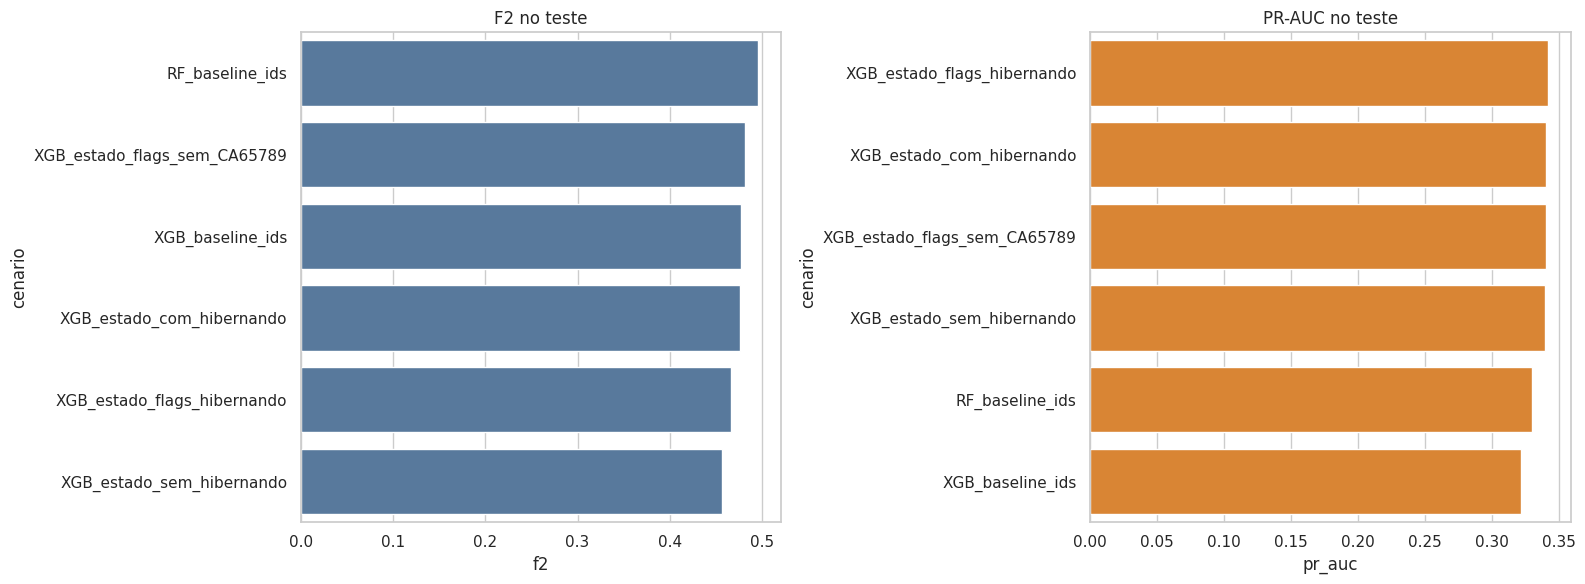

In [6]:
test_metrics = metrics[metrics["split"] == "teste"].copy()
display(
    test_metrics[
        ["cenario", "amostras", "positivas", "threshold", "pr_auc", "precision", "recall", "f2", "predicoes_positivas"]
    ].sort_values("f2", ascending=False)
)

cm_rows = []
for cenario, part in predictions.groupby("cenario"):
    counts = part["erro"].value_counts()
    cm_rows.append({
        "cenario": cenario,
        "TP": int(counts.get("TP", 0)),
        "FP": int(counts.get("FP", 0)),
        "FN": int(counts.get("FN", 0)),
        "TN": int(counts.get("TN", 0)),
    })
cm_summary = pd.DataFrame(cm_rows)
display(cm_summary.merge(test_metrics[["cenario", "precision", "recall", "f2"]], on="cenario").sort_values("f2", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=test_metrics.sort_values("f2", ascending=False), x="f2", y="cenario", ax=axes[0], color="#4C78A8")
axes[0].set(title="F2 no teste")
sns.barplot(data=test_metrics.sort_values("pr_auc", ascending=False), x="pr_auc", y="cenario", ax=axes[1], color="#F58518")
axes[1].set(title="PR-AUC no teste")
plt.tight_layout()
plt.show()

## 6. Efeito específico de `Hibernando`

Comparamos três perguntas:

1. estado operacional sem `Hibernando` melhora o baseline?
2. incluir `Hibernando` melhora ou piora?
3. remover `CA65789` muda a leitura do cenário com flags de hibernação?

In [7]:
compare_cols = ["cenario", "amostras", "positivas", "pr_auc", "precision", "recall", "f2", "predicoes_positivas"]
hib_compare = test_metrics[test_metrics["cenario"].isin([
    "XGB_baseline_ids",
    "XGB_estado_sem_hibernando",
    "XGB_estado_com_hibernando",
    "XGB_estado_flags_hibernando",
    "XGB_estado_flags_sem_CA65789",
])][compare_cols].sort_values("f2", ascending=False)
display(hib_compare)

tag_error = (
    predictions[predictions["cenario"].isin(["XGB_baseline_ids", "XGB_estado_flags_hibernando"])]
    .assign(FP=lambda d: (d["erro"] == "FP").astype(int), FN=lambda d: (d["erro"] == "FN").astype(int))
    .groupby(["cenario", "TAG", "Tipo"])
    .agg(FP=("FP", "sum"), FN=("FN", "sum"), positivos=("target", "sum"), amostras=("target", "size"))
    .reset_index()
)
display(tag_error.sort_values(["cenario", "FN"], ascending=[True, False]).groupby("cenario").head(10))
display(tag_error.sort_values(["cenario", "FP"], ascending=[True, False]).groupby("cenario").head(10))

,cenario,amostras,positivas,pr_auc,precision,recall,f2,predicoes_positivas
11,XGB_estado_flags_sem_CA65789,3026,287,0.339934,0.187192,0.794425,0.481826,1218
3,XGB_baseline_ids,3115,290,0.321870,0.183043,0.796552,0.476879,1262
7,XGB_estado_com_hibernando,3115,290,0.340548,0.201932,0.720690,0.476082,1035
9,XGB_estado_flags_hibernando,3115,290,0.341530,0.190647,0.731034,0.466549,1112
5,XGB_estado_sem_hibernando,3115,290,0.339557,0.244573,0.582759,0.456510,691


,cenario,TAG,Tipo,FP,FN,positivos,amostras
27,XGB_baseline_ids,CA65935,Caminhao,26,8,17,89
28,XGB_baseline_ids,CA65936,Caminhao,35,7,23,89
1,XGB_baseline_ids,CA5927,Caminhao,56,5,14,89
19,XGB_baseline_ids,CA65927,Caminhao,35,4,27,89
25,XGB_baseline_ids,CA65933,Caminhao,56,4,20,89
0,XGB_baseline_ids,CA5926,Caminhao,49,3,11,89
2,XGB_baseline_ids,CA65789,Caminhao,23,3,3,89
13,XGB_baseline_ids,CA65921,Caminhao,40,3,16,89
16,XGB_baseline_ids,CA65924,Caminhao,41,3,10,89
18,XGB_baseline_ids,CA65926,Caminhao,25,3,55,89


,cenario,TAG,Tipo,FP,FN,positivos,amostras
5,XGB_baseline_ids,CA65792,Caminhao,68,1,12,89
21,XGB_baseline_ids,CA65929,Caminhao,62,0,1,89
11,XGB_baseline_ids,CA65916,Caminhao,61,0,1,89
26,XGB_baseline_ids,CA65934,Caminhao,57,0,2,89
1,XGB_baseline_ids,CA5927,Caminhao,56,5,14,89
25,XGB_baseline_ids,CA65933,Caminhao,56,4,20,89
22,XGB_baseline_ids,CA65930,Caminhao,50,1,6,89
0,XGB_baseline_ids,CA5926,Caminhao,49,3,11,89
10,XGB_baseline_ids,CA65915,Caminhao,49,1,6,89
16,XGB_baseline_ids,CA65924,Caminhao,41,3,10,89


## 7. Leitura final

Critérios para decisão:

- se `XGB_baseline_ids` superar claramente `RF_baseline_ids`, há ganho de algoritmo sem mudar dados;
- se features de estado melhorarem PR-AUC/F2 sem explodir falsos positivos, apontamentos ajudam;
- se `Hibernando` piorar ou concentrar falsos positivos, deve ser isolado ou removido;
- se remover `CA65789` mudar muito o resultado, essa TAG precisa de tratamento experimental próprio;
- se o ganho for marginal, o próximo investimento deve ir para famílias de alarmes e janelas, não para
  estados operacionais.